# Seq2Seq Document Generation — Interactive Demo

This notebook demonstrates the trained Bahdanau-attention Seq2Seq model end-to-end:

1. Load trained checkpoint + vocabularies
2. Generate summaries with **greedy** and **beam search** decoding
3. Visualize **attention heatmaps** proving the model learned source→target alignment
4. Inspect training curves

**Model:** Bidirectional GRU Encoder + Bahdanau (Additive) Attention + GRU Decoder | 3.9M params | 15 epochs | Best Val PPL: **9.08**

## 1. Setup — Load Model and Vocabularies

In [1]:
import os, sys, json, torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, 'src')
from model import build_model
from inference import generate_document, greedy_decode, beam_search_decode
from preprocessing import Vocabulary, tokenize

device = torch.device('cpu')

src_vocab = Vocabulary.load('data/src_vocab.pkl')
tgt_vocab = Vocabulary.load('data/tgt_vocab.pkl')
print(f'Source vocab: {len(src_vocab)} tokens | Target vocab: {len(tgt_vocab)} tokens')

model = build_model(
    src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
    embed_dim=256, hidden_dim=256, attention_dim=128,
    n_layers=2, dropout=0.3,
    pad_idx=Vocabulary.PAD_IDX, sos_idx=Vocabulary.SOS_IDX, device=device,
)

ckpt = torch.load('models/best_model.pt', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

print(f"\nLoaded checkpoint from epoch {ckpt['epoch']}")
print(f"Best val_loss: {ckpt['val_loss']:.4f}  |  PPL: {np.exp(ckpt['val_loss']):.2f}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Source vocab: 615 tokens | Target vocab: 285 tokens
  Model parameters: 3,907,229 total, 3,907,229 trainable

Loaded checkpoint from epoch 15
Best val_loss: 2.2062  |  PPL: 9.08
Total parameters: 3,907,229


## 2. Training Curves

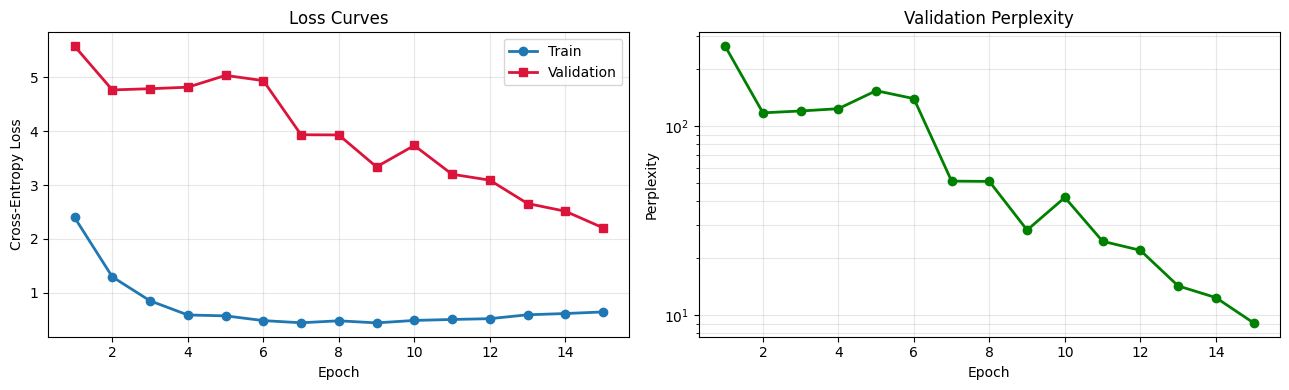

In [2]:
with open('models/training_history.json') as f:
    hist = json.load(f)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
epochs = [h['epoch'] for h in hist]
ax[0].plot(epochs, [h['train_loss'] for h in hist], 'o-', label='Train', linewidth=2)
ax[0].plot(epochs, [h['val_loss'] for h in hist], 's-', label='Validation', linewidth=2, color='crimson')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Cross-Entropy Loss')
ax[0].set_title('Loss Curves'); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(epochs, [h['val_ppl'] for h in hist], 'o-', color='green', linewidth=2)
ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Perplexity'); ax[1].set_yscale('log')
ax[1].set_title('Validation Perplexity'); ax[1].grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

## 3. Document Generation — Greedy vs Beam Search

Three test documents covering the domains the model was trained on: financial reports, product specs, and research abstracts.

In [3]:
test_sources = [
    ("Financial Report",
     "The quarterly financial report for TechNova indicates revenue of $2500M, "
     "representing a 15% increase year over year. Operating expenses increased to $1200M. "
     "Net income was $450M. The board approved a dividend of $2.50 per share. "
     "Management projects continued growth driven by AI integration."),

    ("Product Spec",
     "The ProMax X1 by CloudPeak features a 8-core processor, 6000mAh battery, "
     "and AI-powered assistant. Available in Black, Silver, and Blue, the device "
     "weighs 195g and includes fast charging and biometric auth. Pricing starts at $999."),

    ("Research Abstract",
     "This study examines the relationship between remote work frequency and productivity "
     "using a dataset of 5000 observations from Fortune 500 companies. We employ regression "
     "analysis to analyze temporal patterns. Results indicate a strong positive correlation "
     "(p < 0.001). The findings suggest that targeted interventions improve outcomes."),
]

for title, source in test_sources:
    print(f'\n{"="*70}\n{title}\n{"="*70}')
    print(f'SOURCE:\n  {source[:200]}...\n')

    greedy, _ = generate_document(model, source, src_vocab, tgt_vocab,
                                   method='greedy', max_len=60, device=device)
    print(f'GREEDY:  {greedy}')

    beam, bmeta = generate_document(model, source, src_vocab, tgt_vocab,
                                     method='beam', beam_width=5, max_len=60, device=device)
    print(f'BEAM(5): {beam}  (log-prob: {bmeta["score"]:.4f})')


Financial Report
SOURCE:
  The quarterly financial report for TechNova indicates revenue of $2500M, representing a 15% increase year over year. Operating expenses increased to $1200M. Net income was $450M. The board approved a ...

GREEDY:  Technova reported hit.9m revenue, increase increase.2 yoy with 754 operating net.


BEAM(5): Technova reported hit.9m revenue, increase increase growth yoy with.7 operating margin.  (log-prob: -0.3703)

Product Spec
SOURCE:
  The ProMax X1 by CloudPeak features a 8-core processor, 6000mAh battery, and AI-powered assistant. Available in Black, Silver, and Blue, the device weighs 195g and includes fast charging and biometric...

GREEDY:  New promax x1 by cloudpeak processor 8-core processor battery launching from at.
BEAM(5): New promax x1 by cloudpeak processor 8-core 6000mah battery launching from at.  (log-prob: -0.2520)

Research Abstract
SOURCE:
  This study examines the relationship between remote work frequency and productivity using a dataset of 5000 observations from Fortune 500 companies. We employ regression analysis to analyze temporal p...

GREEDY:  Study finds for positive correlation between remote work frequency and productivity p 0.001 using regression analysis.


BEAM(5): Study finds for positive correlation between remote work frequency and productivity p 0.001 using regression analysis.  (log-prob: -0.2040)


## 4. Attention Heatmap — Proof the Model Learned Alignment

The attention heatmap shows which source tokens the decoder attended to when emitting each output token.
Strong diagonal or localized patterns indicate the model has learned meaningful source→target alignment
(not just memorized n-grams).

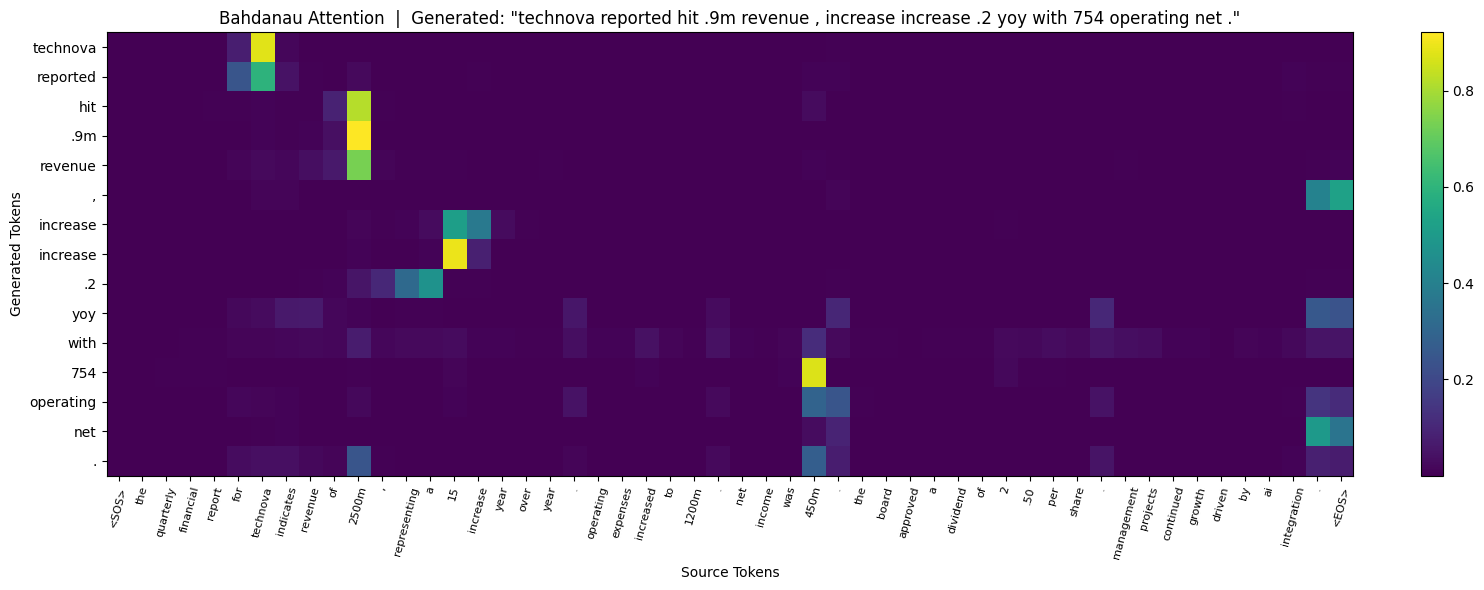

In [4]:
def plot_attention(source_text, max_len=60):
    tokens = tokenize(source_text)
    indices = src_vocab.encode(tokens)
    src_tensor = torch.tensor([indices], dtype=torch.long, device=device)
    src_length = torch.tensor([len(indices)], dtype=torch.long, device=device)

    out_tokens, attn = greedy_decode(model, src_tensor, src_length, tgt_vocab,
                                      max_len=max_len, device=device)
    attn = attn.cpu().numpy()

    src_display = ['<SOS>'] + tokens + ['<EOS>']
    attn = attn[:len(out_tokens), :len(src_display)]

    fig, ax = plt.subplots(figsize=(max(10, len(tokens) * 0.3), max(4, len(out_tokens) * 0.4)))
    im = ax.imshow(attn, cmap='viridis', aspect='auto')
    ax.set_xticks(range(len(src_display)))
    ax.set_xticklabels(src_display, rotation=75, fontsize=8)
    ax.set_yticks(range(len(out_tokens)))
    ax.set_yticklabels(out_tokens, fontsize=10)
    ax.set_xlabel('Source Tokens')
    ax.set_ylabel('Generated Tokens')
    ax.set_title(f'Bahdanau Attention  |  Generated: "{" ".join(out_tokens)}"')
    plt.colorbar(im, ax=ax, fraction=0.025)
    plt.tight_layout()
    plt.show()

# Financial report attention
plot_attention(test_sources[0][1])

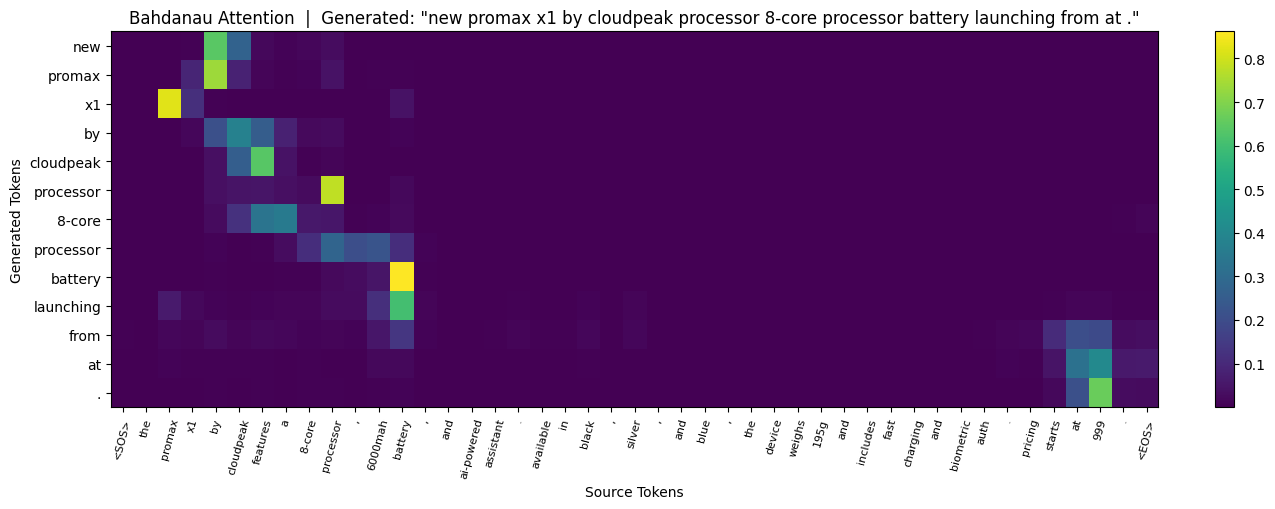

In [5]:
# Product spec attention
plot_attention(test_sources[1][1])

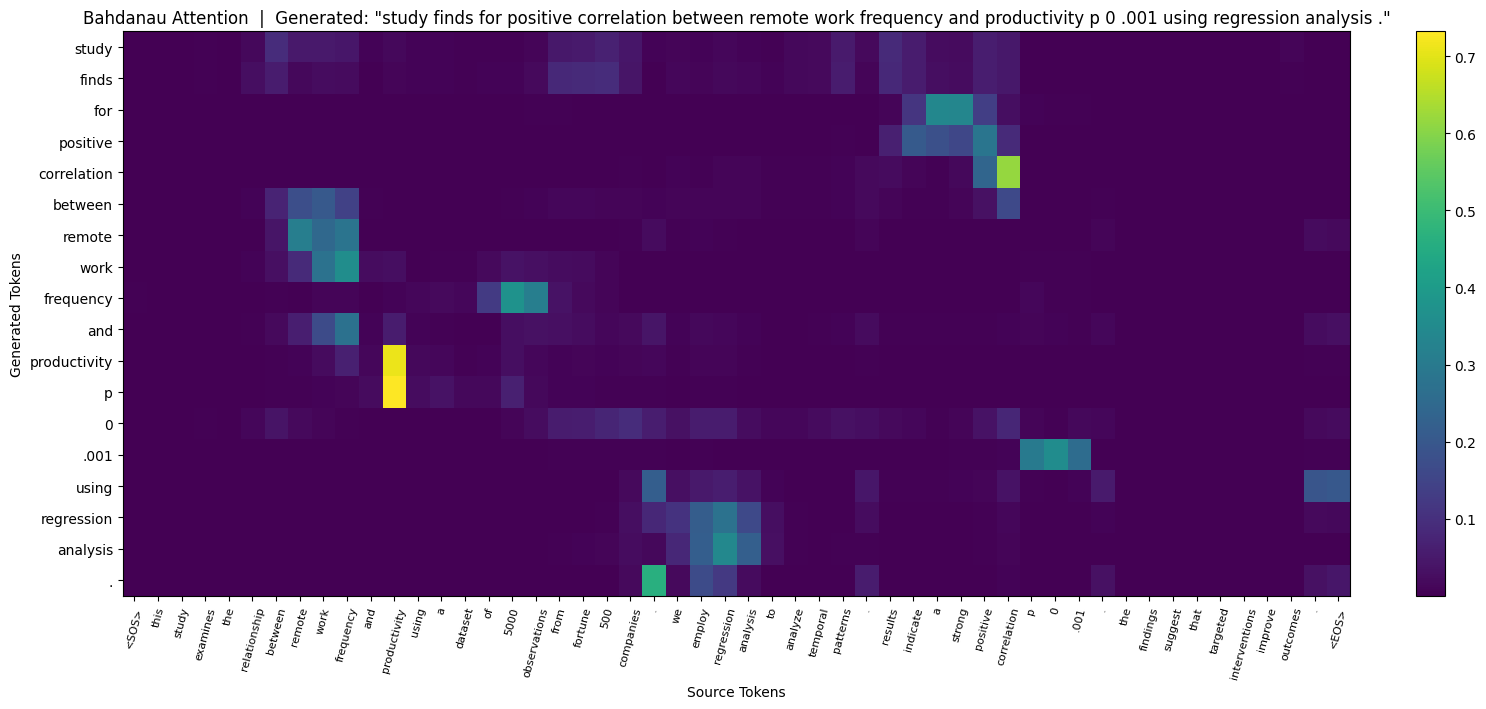

In [6]:
# Research abstract attention
plot_attention(test_sources[2][1])

## 5. Try Your Own Input

Edit the cell below and re-run to generate on custom text.

In [7]:
custom = 'Your source document here...'

greedy, _ = generate_document(model, custom, src_vocab, tgt_vocab,
                               method='greedy', max_len=60, device=device)
beam, bmeta = generate_document(model, custom, src_vocab, tgt_vocab,
                                 method='beam', beam_width=5, max_len=60, device=device)
print('GREEDY:', greedy)
print('BEAM  :', beam)

GREEDY: New reported: 8-core revenue, increase -1 growth, with.7 operating margin.
BEAM  : New earnings hit: revenue, increase.3 growth, with.7 operating margin.
